<a href="https://colab.research.google.com/github/Keistkmiya/Tugas2-MachineLearning/blob/main/Tugas2_Chapter7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 7: Model Evaluation

## Setup and Library Imports


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

url_ev = "https://data.wa.gov/api/views/f6w7-q2d2/rows.csv?accessType=DOWNLOAD"
df_ev = pd.read_csv(url_ev)
df_ev.columns = [col.lower().replace(' ', '_') for col in df_ev.columns]

target_cols = ['model_year', 'electric_range', 'base_msrp']
numeric_cols = [col for col in target_cols if col in df_ev.columns]
df_eval = df_ev.dropna(subset=numeric_cols + ['electric_vehicle_type']).copy()

y = (df_eval['electric_vehicle_type'] == 'Battery Electric Vehicle (BEV)').astype(int)
X = df_eval[numeric_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Setup Chapter 7 Berhasil!")
print(f"Ukuran Data Training: {X_train.shape}")
print(f"Ukuran Data Testing: {X_test.shape}")

Setup Chapter 7 Berhasil!
Ukuran Data Training: (224656, 2)
Ukuran Data Testing: (56165, 2)


## Cross-Validating Models

Dalam evaluasi model, membagi data menjadi *train* dan *test* set (biasanya 80/20) adalah hal yang standar. Namun, hasil akurasi model bisa sangat bergantung pada baris data mana yang masuk ke dalam *test set*.

**K-Fold Cross-Validation** menyelesaikan masalah ini dengan cara:
1. Membagi data menjadi $k$ kelompok (*folds*) yang sama besar (misal $k=5$).
2. Model dilatih pada 4 kelompok dan diuji pada 1 kelompok.
3. Proses ini diulang 5 kali, di mana setiap kelompok mendapat giliran menjadi *test set* tepat satu kali.

Hasil akhirnya adalah **rata-rata** dari kelima pengujian tersebut, yang memberikan kita gambaran performa model yang jauh lebih stabil dan dapat diandalkan.

In [2]:
from sklearn.model_selection import cross_val_score

model_cv = LogisticRegression(max_iter=1000)
scores = cross_val_score(model_cv, X, y, cv=5, scoring='accuracy')

print("Hasil 5 putaran Cross-Validation:")
for i, score in enumerate(scores):
    print(f"Putaran {i+1}: {score:.4f} ({score:.2%})")

print(f"\nRata-rata Akurasi: {scores.mean():.4f} ({scores.mean():.2%})")
print(f"Standar Deviasi: {scores.std():.4f} (Semakin kecil, model semakin stabil)")

Hasil 5 putaran Cross-Validation:
Putaran 1: 0.8043 (80.43%)
Putaran 2: 0.8115 (81.15%)
Putaran 3: 0.8109 (81.09%)
Putaran 4: 0.8096 (80.96%)
Putaran 5: 0.8102 (81.02%)

Rata-rata Akurasi: 0.8093 (80.93%)
Standar Deviasi: 0.0026 (Semakin kecil, model semakin stabil)


## Evaluating Performance with Confusion Matrices

Confusion Matrix adalah tabel yang merangkum seberapa baik model klasifikasi kita bekerja. Ia membagi hasil prediksi menjadi empat kategori utama:

1. **True Positives (TP):** Model menebak BEV, dan memang benar BEV.
2. **True Negatives (TN):** Model menebak PHEV (Bukan BEV), dan memang benar bukan BEV.
3. **False Positives (FP):** Model menebak BEV, padahal aslinya PHEV (Tipe I Error).
4. **False Negatives (FN):** Model menebak PHEV, padahal aslinya BEV (Tipe II Error).

Dengan melihat tabel ini, kita bisa tahu di mana tepatnya model kita "bingung" (*confused*).

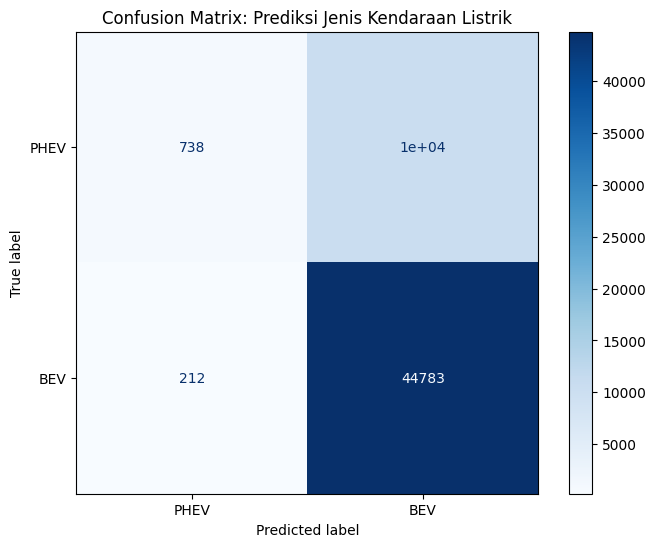

True Negatives (PHEV Terdeteksi Benar): 738
False Positives (PHEV Salah Tebak BEV): 10432
False Negatives (BEV Salah Tebak PHEV): 212
True Positives (BEV Terdeteksi Benar): 44783


In [3]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['PHEV', 'BEV'])

fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(cmap='Blues', ax=ax)
plt.title('Confusion Matrix: Prediksi Jenis Kendaraan Listrik')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (PHEV Terdeteksi Benar): {tn}")
print(f"False Positives (PHEV Salah Tebak BEV): {fp}")
print(f"False Negatives (BEV Salah Tebak PHEV): {fn}")
print(f"True Positives (BEV Terdeteksi Benar): {tp}")

## Evaluating Models Using Precision, Recall, and F1-Score

Metrik akurasi bisa sangat menyesatkan jika dataset kita tidak seimbang (misalnya, jika 90% data adalah BEV). Oleh karena itu, kita membutuhkan tiga metrik utama ini:

*   **Precision:** Dari semua yang ditebak positif (BEV) oleh model, berapa banyak yang benar-benar positif? Ini sangat penting jika kita ingin menghindari kesalahan "salah tuduh" (False Positive).
*   **Recall (Sensitivity):** Dari semua data yang aslinya positif (BEV), berapa banyak yang berhasil dideteksi oleh model? Ini penting jika kita tidak ingin ada data yang "lolos" (False Negative).
*   **F1-Score:** Rata-rata harmonik antara Precision dan Recall. Metrik ini memberikan satu angka tunggal yang menyeimbangkan keduanya.

Berikut adalah formula matematisnya:

$$Precision = \frac{TP}{TP + FP}$$

$$Recall = \frac{TP}{TP + FN}$$

$$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$

In [4]:
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print("\nClassification Report Lengkap:")
print(classification_report(y_test, y_pred, target_names=['PHEV', 'BEV']))

Precision: 0.8111
Recall   : 0.9953
F1-Score : 0.8938

Classification Report Lengkap:
              precision    recall  f1-score   support

        PHEV       0.78      0.07      0.12     11170
         BEV       0.81      1.00      0.89     44995

    accuracy                           0.81     56165
   macro avg       0.79      0.53      0.51     56165
weighted avg       0.80      0.81      0.74     56165



## Visualizing Performance with ROC and AUC

**ROC (Receiver Operating Characteristic)** adalah kurva yang memplot dua parameter utama:
1. **True Positive Rate (TPR)**: Sama dengan Recall ($TPR = \frac{TP}{TP + FN}$).
2. **False Positive Rate (FPR)**: Rasio seberapa sering model salah menebak positif ($FPR = \frac{FP}{FP + TN}$).

Kurva ROC menunjukkan *trade-off* antara sensivitas (TPR) dan spesifisitas (1-FPR).

**AUC (Area Under the ROC Curve)** adalah angka tunggal yang mengukur seluruh area di bawah kurva ROC.
*   **AUC = 1.0**: Model sempurna.
*   **AUC = 0.5**: Model tidak lebih baik dari tebakan acak (seperti melempar koin).

Semakin kurvanya mendekati pojok kiri atas, semakin hebat model kita dalam membedakan antara BEV dan PHEV.

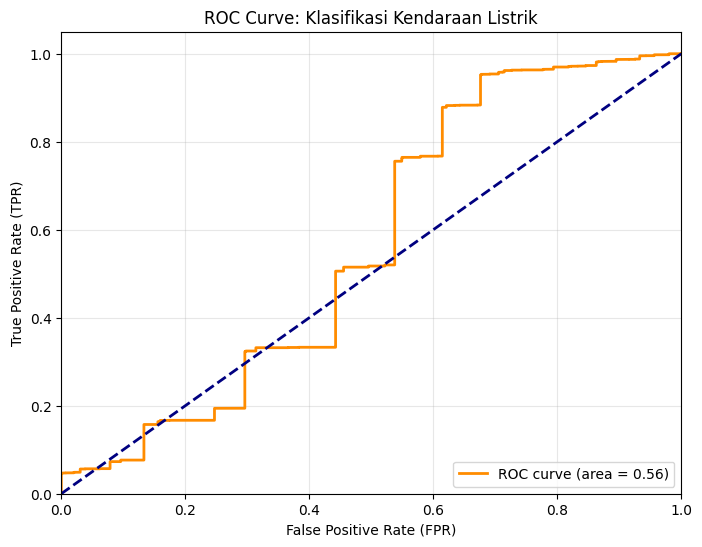

Skor AUC: 0.5632


In [5]:
from sklearn.metrics import roc_curve, roc_auc_score

y_probabilities = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probabilities)
auc_score = roc_auc_score(y_test, y_probabilities)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # Garis acak
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve: Klasifikasi Kendaraan Listrik')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

print(f"Skor AUC: {auc_score:.4f}")

## Visualizing the Effect of Hyperparameters

Setiap model memiliki *hyperparameter* (seperti nilai $C$ pada Logistic Regression) yang mengontrol seberapa kompleks model tersebut.

*   **Underfitting**: Model terlalu sederhana (skor rendah di data latih & uji).
*   **Overfitting**: Model terlalu kompleks (skor tinggi di data latih, tapi anjlok di data uji).

**Validation Curve** membantu kita mencari titik "Sweet Spot" di mana model bekerja optimal pada data baru dengan memplot skor akurasi untuk berbagai nilai parameter.

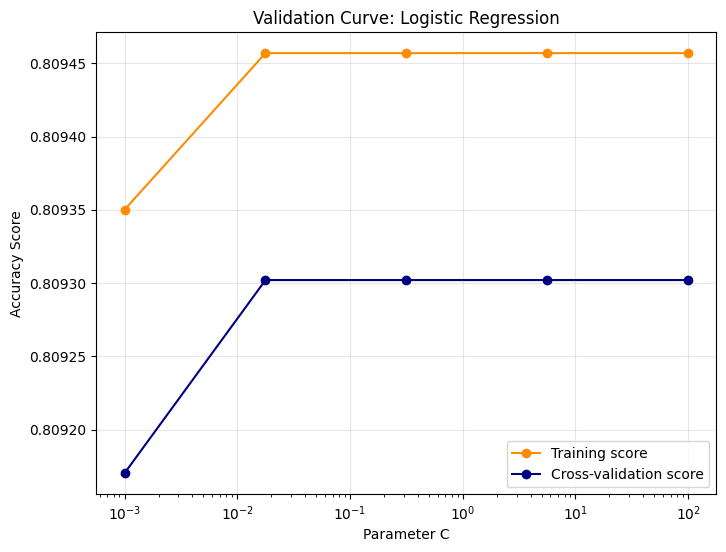

In [6]:
from sklearn.model_selection import validation_curve
import matplotlib.pyplot as plt

param_range = np.logspace(-3, 2, 5)
train_scores, test_scores = validation_curve(
    LogisticRegression(max_iter=1000),
    X, y,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
train_mean = np.mean(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8, 6))
plt.plot(param_range, train_mean, label="Training score", color="darkorange", marker='o')
plt.plot(param_range, test_mean, label="Cross-validation score", color="navy", marker='o')
plt.xscale('log')
plt.title("Validation Curve: Logistic Regression")
plt.xlabel("Parameter C")
plt.ylabel("Accuracy Score")
plt.legend(loc="best")
plt.grid(alpha=0.3)
plt.show()